In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")




In [ ]:
print(pd.__version__)
print(np.__version__)


3.0.1
2.4.2


In [ ]:
# Step 2: Generate synthetic vehicle insurance claims dataset

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

num_records = 10000  # Number of records

# Create empty DataFrame
df = pd.DataFrame()

# Add IDs for realism
df['user_id'] = np.random.randint(1000, 5000, size=num_records)      # unique policyholder ID
df['vehicle_id'] = np.random.randint(2000, 10000, size=num_records)  # unique vehicle ID

# Generate realistic features
df['age'] = np.random.randint(18, 80, size=num_records)             # Policyholder age
df['income'] = np.random.randint(15000, 120000, size=num_records)   # Annual income
df['vehicle_age'] = np.random.randint(0, 20, size=num_records)      # Vehicle age in years
df['past_claims'] = np.random.randint(0, 10, size=num_records)      # Number of past claims
df['claim_amount'] = np.random.normal(loc=5000, scale=2000, size=num_records).round(2)
df['accident_severity'] = np.random.randint(1, 6, size=num_records) # 1=minor, 5=severe

# Optional: Add random timestamps for when claims occurred
start_date = datetime.now() - timedelta(days=730)  # last 2 years
df['timestamp'] = [start_date + timedelta(days=random.randint(0, 730)) for _ in range(num_records)]

# Preview the first 5 rows
df.head()


,user_id,vehicle_id,age,income,vehicle_age,past_claims,claim_amount,accident_severity,timestamp
0,2352,7717,77,61109,15,8,4448.69,2,2024-07-15 11:04:44.513897
1,3841,3414,55,49910,5,9,8269.50,5,2025-06-13 11:04:44.513897
2,4188,7452,71,50629,9,1,4664.09,1,2024-04-03 11:04:44.513897
3,1682,8896,75,71476,0,4,5342.78,4,2025-05-15 11:04:44.513897
4,1803,3427,77,103660,18,9,7887.40,1,2026-01-22 11:04:44.513897


In [ ]:
# Step 3: Inject anomalies for high-risk cases

# Make a copy of the DataFrame to preserve original
df_anomalous = df.copy()

num_anomalies = int(0.05 * num_records)  # 5% of records as high-risk anomalies

# Randomly pick indices for anomalies
anomaly_indices = np.random.choice(df_anomalous.index, size=num_anomalies, replace=False)

for idx in anomaly_indices:
    # High claim amounts
    df_anomalous.at[idx, 'claim_amount'] *= np.random.uniform(2.5, 5.0)

    
    # Young drivers with old cars
    if df_anomalous.at[idx, 'age'] < 25:
        df_anomalous.at[idx, 'vehicle_age'] = np.random.randint(10, 20)
    
    # High past claims
    df_anomalous.at[idx, 'past_claims'] = np.random.randint(5, 10)
    
    # Severe accidents
    df_anomalous.at[idx, 'accident_severity'] = np.random.randint(4, 6)

# Preview first 5 anomalous records
df_anomalous.loc[anomaly_indices[:5]]


,user_id,vehicle_id,age,income,vehicle_age,past_claims,claim_amount,accident_severity,timestamp
6216,3764,2888,52,49357,17,7,10383.119767,4,2024-10-16 11:04:44.513897
6369,4619,7462,61,61131,6,7,15226.496287,4,2025-10-02 11:04:44.513897
9469,4436,9232,31,110399,14,7,34040.879481,4,2025-03-26 11:04:44.513897
7063,3136,6394,51,70923,7,8,14679.024506,5,2025-06-08 11:04:44.513897
1801,1155,7640,61,83663,19,6,32097.490811,4,2024-12-21 11:04:44.513897


In [ ]:
from sklearn.ensemble import IsolationForest
import joblib

# Select numerical features for anomaly detection
features = ['age', 'income', 'vehicle_age', 'past_claims', 'claim_amount', 'accident_severity']

X = df_anomalous[features]

# Initialize Isolation Forest
iso_model = IsolationForest(
    n_estimators=100,        # number of trees
    contamination=0.05,      # expected fraction of anomalies
    random_state=42
)

# import joblib
model = joblib.load("model/anomaly_model_vehicle.joblib")
print(type(model))

# Get anomaly scores (-1 = anomaly, 1 = normal)
df_anomalous['anomaly_label'] = iso_model.predict(X)
df_anomalous['anomaly_score'] = iso_model.score_samples(X)

# Map label to 0=normal, 1=anomaly for clarity
df_anomalous['anomaly_label'] = df_anomalous['anomaly_label'].map({1:0, -1:1})

# Save the trained model for later use
joblib.dump(iso_model, "../model/anomaly_model_vehicle.joblib")

# Preview
df_anomalous.head(10)


,user_id,vehicle_id,age,income,vehicle_age,past_claims,claim_amount,accident_severity,timestamp,anomaly_label,anomaly_score
0,2352,7717,77,61109,15,8,4448.69,2,2024-07-15 11:04:44.513897,0,-0.506665
1,3841,3414,55,49910,5,9,8269.50,5,2025-06-13 11:04:44.513897,0,-0.518711
2,4188,7452,71,50629,9,1,4664.09,1,2024-04-03 11:04:44.513897,0,-0.497188
3,1682,8896,75,71476,0,4,5342.78,4,2025-05-15 11:04:44.513897,0,-0.515518
4,1803,3427,77,103660,18,9,7887.40,1,2026-01-22 11:04:44.513897,1,-0.593390
5,4089,3051,50,42009,8,9,5283.31,3,2024-07-17 11:04:44.513897,0,-0.496960
6,3922,3227,25,87538,18,4,1524.37,3,2025-06-04 11:04:44.513897,0,-0.518966
7,3905,6640,62,60812,19,9,3529.71,1,2024-11-30 11:04:44.513897,0,-0.549259
8,1643,3277,73,38594,17,4,1180.94,4,2024-12-13 11:04:44.513897,0,-0.523775
9,1324,5243,34,81129,10,4,4726.74,1,2025-12-29 11:04:44.513897,0,-0.462595


In [ ]:
# Step 5: Risk scoring function

def score_risk(row):
    score = 0
    explanation = []

    # 1. Use anomaly score
    if row['anomaly_score'] < -0.5:  # more negative = more anomalous in Isolation Forest
        score += 2
        explanation.append("Unusual claim pattern detected")

    # 2. Vehicle age + young driver risk
    if row['vehicle_age'] > 10 and row['age'] < 25:
        score += 2
        explanation.append("Young driver with old vehicle")

    # 3. High number of past claims
    if row['past_claims'] >= 5:
        score += 1
        explanation.append("Multiple past claims")

    # 4. Severe accident
    if row['accident_severity'] >= 4:
        score += 1
        explanation.append("Severe accident")

    # Assign risk level
    if score >= 4:
        risk = "High"
    elif score >= 2:
        risk = "Medium"
    else:
        risk = "Low"

    return pd.Series([risk, "; ".join(explanation)])

# Apply to dataset
df_anomalous[['risk_level', 'risk_explanation']] = df_anomalous.apply(score_risk, axis=1)

# Preview first 10 scored records
df_anomalous.head(10)


,user_id,vehicle_id,age,income,vehicle_age,past_claims,claim_amount,accident_severity,timestamp,anomaly_label,anomaly_score,risk_level,risk_explanation
0,2352,7717,77,61109,15,8,4448.69,2,2024-07-15 11:04:44.513897,0,-0.506665,Medium,Unusual claim pattern detected; Multiple past ...
1,3841,3414,55,49910,5,9,8269.50,5,2025-06-13 11:04:44.513897,0,-0.518711,High,Unusual claim pattern detected; Multiple past ...
2,4188,7452,71,50629,9,1,4664.09,1,2024-04-03 11:04:44.513897,0,-0.497188,Low,
3,1682,8896,75,71476,0,4,5342.78,4,2025-05-15 11:04:44.513897,0,-0.515518,Medium,Unusual claim pattern detected; Severe accident
4,1803,3427,77,103660,18,9,7887.40,1,2026-01-22 11:04:44.513897,1,-0.593390,Medium,Unusual claim pattern detected; Multiple past ...
5,4089,3051,50,42009,8,9,5283.31,3,2024-07-17 11:04:44.513897,0,-0.496960,Low,Multiple past claims
6,3922,3227,25,87538,18,4,1524.37,3,2025-06-04 11:04:44.513897,0,-0.518966,Medium,Unusual claim pattern detected
7,3905,6640,62,60812,19,9,3529.71,1,2024-11-30 11:04:44.513897,0,-0.549259,Medium,Unusual claim pattern detected; Multiple past ...
8,1643,3277,73,38594,17,4,1180.94,4,2024-12-13 11:04:44.513897,0,-0.523775,Medium,Unusual claim pattern detected; Severe accident
9,1324,5243,34,81129,10,4,4726.74,1,2025-12-29 11:04:44.513897,0,-0.462595,Low,


Risk Level Counts:
 risk_level
Medium    4956
Low       3167
High      1877
Name: count, dtype: int64


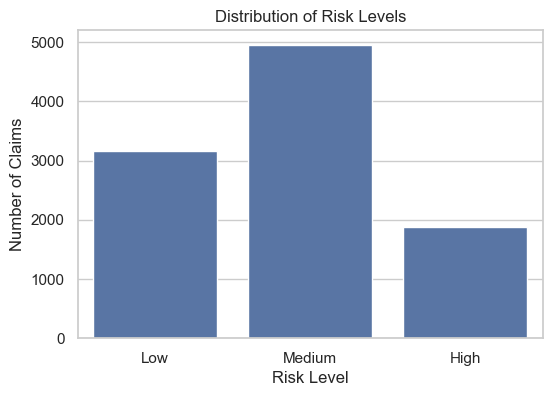

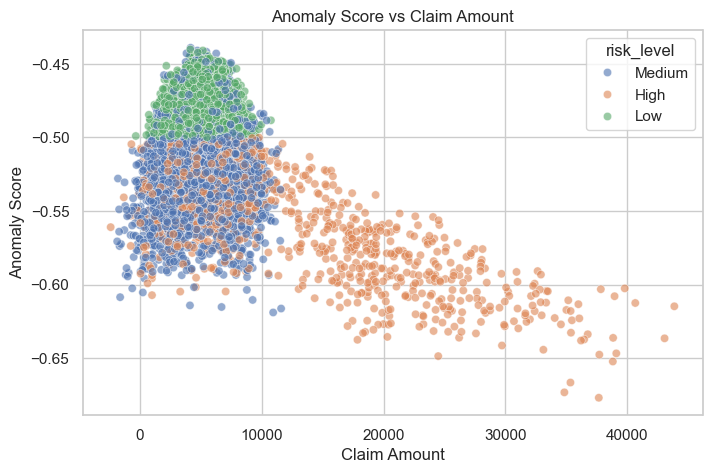

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count of risk levels
risk_counts = df_anomalous['risk_level'].value_counts()
print("Risk Level Counts:\n", risk_counts)

# 2. Plot risk level distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_anomalous, x='risk_level', order=['Low','Medium','High'])
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Claims")
plt.show()

# 3. Optional: Visualize anomaly scores vs claim amount
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_anomalous, x='claim_amount', y='anomaly_score', hue='risk_level', alpha=0.6)
plt.title("Anomaly Score vs Claim Amount")
plt.xlabel("Claim Amount")
plt.ylabel("Anomaly Score")
plt.show()


In [ ]:
import joblib

# Save the trained model
joblib.dump(model, r"C:\temp\intelligent-risk-system\models\risk_model.pkl")


NameError: name 'model' is not defined

In [ ]:
import joblib

joblib.dump(iso_model, r"C:\temp\intelligent-risk-system\models\risk_model.pkl")


In [ ]:
import joblib
joblib.dump(iso_model, r"C:\temp\intelligent-risk-system\models\risk_model.pkl")


['C:\\temp\\intelligent-risk-system\\models\\risk_model.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# Load labeled dataset
df = pd.read_csv("data/your_dataset_labeled.csv")

# Features
X = df[["age", "income", "vehicle_age", "past_claims", "claim_amount", "accident_severity"]]

# Labels
y = df["risk_level"]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(rf_model, "model/rf_model_vehicle.pkl")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import pandas as pd

# Load labeled dataset
df = pd.read_csv("data/your_dataset_labeled.csv")

# Features
X = df[["age","income","vehicle_age","past_claims","claim_amount","accident_severity"]]

# Labels
y = df["risk_level"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(rf_model, "model/rf_model_vehicle.pkl")